# Загрузка и обработка данных
# 1. Загрузка данных

## 1.1 Импорт библиотек

**Какие инструменты используются:** `pandas` для обычных таблиц, `geopandas` для GeoJSON и пространственных операций, `numpy` для числовых диапазонов, `shapely.Point` для создания точек по координатам, `tqdm` для progress bar, `matplotlib` для графиков.

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import shutil
from shapely import Point
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
tqdm.pandas()
import warnings
warnings.filterwarnings('ignore')

## 1.2  Загрузка начального датасэта с информацией о погодных данных в Краснодарском крае
- **Назначение:** загружается основная климатическая таблица `Extended_climate_data.csv`.
- **Какие данные содержит таблица:** дата наблюдения, широта `lat`, долгота `lon`, осадки, температура, максимум/минимум температуры, солнечная радиация, скорость и направление ветра.
- **Создаётся:** датафрейм `Climate_data`, который дальше будет расширяться геометрией, муниципалитетами, полигонами, календарными признаками и внешними признаками.

In [2]:
Climate_data = pd.read_csv('Extended_climate_data.csv')

In [3]:
Climate_data.head(5)

,date,lat,lon,precipitation,temp,tmax,tmin,solar_radiation,wind_speed,wind_direction
0,1995-01-01,43.5,40.0,18.509764,6.036652,7.311920,NaN,863494.56,4.532644,126.136700
1,1995-01-01,43.6,39.7,18.866320,6.425415,7.884186,5.164581,NaN,6.660660,133.719160
2,1995-01-01,43.6,39.8,18.317719,5.957062,7.624420,NaN,933046.30,5.878768,NaN
3,1995-01-01,43.6,39.9,18.058750,4.948761,6.452545,3.695831,970855.56,4.640729,120.062291
4,1995-01-01,43.6,40.0,17.797548,4.028259,5.477936,2.764801,1007383.70,3.449704,132.303010


## 1.3 Загрузка дополнительной таблицы с информацией по границам муниципалитетов Краснодарского края 
- **Назначение:** загружается GeoJSON с границами муниципалитетов Краснодарского края.
- **Какие данные используются:** файл `Krasnodar_Municipalities_GeoJson.txt`; в нём есть названия районов/округов (`r_reg_name`) и геометрия границ (`geometry`) в формате `MultiPolygon`.
- **Что создаётся:** GeoDataFrame `municipalities`, который используется для определения района по точке и для добавления столбца `region_polygon`.
- **Почему задаётся CRS:** `EPSG:4326` означает координаты широта/долгота; это должно совпадать с координатами климатических точек.
- **Вывод:** после этой ячейки у нас есть справочник границ муниципалитетов.

In [4]:
municipalities = gpd.read_file('Krasnodar_Municipalities_GeoJson.txt')
municipalities.crs = 'EPSG:4326'

## 1.4 Добавим объект `geometry` в датасет `Climate_data`
- **Назначение:** каждая строка климатической таблицы превращается в географическую точку.
- **Какие данные используются:** столбцы `lon` и `lat` из `Climate_data`.
- **Что создаётся:** столбец `geometry`, где каждая запись имеет вид `POINT (lon lat)`.
- **Зачем это нужно:** без `geometry` нельзя проверить, в какой муниципальный полигон попадает климатическая точка.

In [5]:
Climate_data['geometry'] = Climate_data.apply(lambda x: Point(x['lon'], x['lat']), axis=1)

In [6]:
Climate_data.crs = 'EPSG:4326'

In [7]:
Climate_data.head()

,date,lat,lon,precipitation,temp,tmax,tmin,solar_radiation,wind_speed,wind_direction,geometry
0,1995-01-01,43.5,40.0,18.509764,6.036652,7.311920,NaN,863494.56,4.532644,126.136700,POINT (40 43.5)
1,1995-01-01,43.6,39.7,18.866320,6.425415,7.884186,5.164581,NaN,6.660660,133.719160,POINT (39.7 43.6)
2,1995-01-01,43.6,39.8,18.317719,5.957062,7.624420,NaN,933046.30,5.878768,NaN,POINT (39.8 43.6)
3,1995-01-01,43.6,39.9,18.058750,4.948761,6.452545,3.695831,970855.56,4.640729,120.062291,POINT (39.9 43.6)
4,1995-01-01,43.6,40.0,17.797548,4.028259,5.477936,2.764801,1007383.70,3.449704,132.303010,POINT (40 43.6)


## 1.5 Добавление названия муниципалитета для каждой строки климатической таблицы
- **Назначение:** строится словарь соответствия `точка -> муниципалитет` для климатических точек.
- **Какие данные используются:** уникальные точки из `Climate_data['geometry']` и полигоны из `municipalities`.
- **Как работает:** для каждой уникальной точки перебираются муниципальные полигоны; если полигон покрывает точку, сохраняется название района/округа `r_reg_name`.
- **Вывод:** эта ячейка связывает сеточные климатические координаты с административными территориями.


In [8]:
map_ = {}
unique_points = Climate_data['geometry'].unique()
for current_point in tqdm(unique_points, desc='Добавление названия адм. единицы к каждой точке'):
    for _, row in municipalities.iterrows():
        if row['geometry'].covers(current_point):
            map_[current_point] = row['r_reg_name']
            break
    else:
        map_['current_point'] = -1

Добавление названия адм. единицы к каждой точке:   0%|          | 0/851 [00:00<?, ?it/s]

- **Назначение:** добавляется название муниципалитета для каждой строки климатической таблицы.
- **Что создаётся:** столбец `municipality`.
- **Что означает `-1`:** точка не попала ни в один муниципальный полигон; такие строки дальше рассматриваются как пространственные выбросы.
- **Вывод:** теперь каждое наблюдение можно группировать по району/городскому округу.

In [9]:
Climate_data['municipality'] = Climate_data.progress_apply(lambda x: map_.get(x['geometry'], -1), axis=1)

  0%|          | 0/9675019 [00:00<?, ?it/s]

In [10]:
Climate_data.head(5)

,date,lat,lon,precipitation,temp,tmax,tmin,solar_radiation,wind_speed,wind_direction,geometry,municipality
0,1995-01-01,43.5,40.0,18.509764,6.036652,7.311920,NaN,863494.56,4.532644,126.136700,POINT (40 43.5),городской округ Сочи
1,1995-01-01,43.6,39.7,18.866320,6.425415,7.884186,5.164581,NaN,6.660660,133.719160,POINT (39.7 43.6),-1
2,1995-01-01,43.6,39.8,18.317719,5.957062,7.624420,NaN,933046.30,5.878768,NaN,POINT (39.8 43.6),городской округ Сочи
3,1995-01-01,43.6,39.9,18.058750,4.948761,6.452545,3.695831,970855.56,4.640729,120.062291,POINT (39.9 43.6),городской округ Сочи
4,1995-01-01,43.6,40.0,17.797548,4.028259,5.477936,2.764801,1007383.70,3.449704,132.303010,POINT (40 43.6),городской округ Сочи


# Итоговый датасэт собран. Проведем обработку и расширение данных с целью обучения более точной модели

# 2. Обработка и чистка данных

## 2.1 Подсчитаем пропуски в каждом столбце
### Эта проверка показывает, какие признаки нужно интерполировать, удалить или обработать отдельно.


In [11]:
Climate_data.isna().sum()

date                    0
lat                     0
lon                     0
precipitation      677559
temp               678118
tmax               676728
tmin               678109
solar_radiation    678542
wind_speed         676892
wind_direction     676912
geometry                0
municipality            0
dtype: int64

### Как мы видим, пропуски есть в колонках:
- precipitation
- temp
- tmax               
- tmin                   
- solar_radiation    
- wind_speed         
- wind_direction     

Напишем фнукцию для обработки пропусков. Существует много стратегий для заполнения пропусков, однако в нашем случае видна **временная закономерность**. Поэтому заполняем пропуски с помощью `линейной интерполяции`.

## 2.2 Функция заполнения пропусков в столбцах
- **Назначение:** создаётся функция для заполнения пропусков в числовых колонках.
- **Как работает:** для каждого столбца применяется линейная интерполяция `interpolate(method='linear')`.

In [12]:
def fill_na(df, cols: list):
    for col in cols:
        df.loc[:, col] = df.loc[:, col].interpolate(method='linear')
    return df

### Применим функцию ля заполнения пропусков в столбцах 

- precipitation
- temp
- tmax               
- tmin                   
- solar_radiation    
- wind_speed         
- wind_direction  

In [13]:
Climate_data = fill_na(Climate_data, cols=['precipitation', 'temp', 'tmin', 'tmax', 'solar_radiation', 'wind_speed', 'wind_direction'])
Climate_data = Climate_data.dropna(subset=['tmin'])

### Убедимся, что пропусков нет

In [14]:
Climate_data.isna().sum()

date               0
lat                0
lon                0
precipitation      0
temp               0
tmax               0
tmin               0
solar_radiation    0
wind_speed         0
wind_direction     0
geometry           0
municipality       0
dtype: int64

## 2.3 Проверим наличие выбросов в наборе `Climate_data`.

Когда мы добавляли метку `municipality`, мы оставили метку `-1` для точек, не входящих в регион. 
**Это и есть наши пространственные выбросы.**

- **Назначение:** выделяются строки, которые не попали ни в один муниципалитет.
- **Какие данные используются:** столбец `municipality`, где значение `-1` означает отсутствие найденного района.
- **Что создаётся:** датафрейм `outlayers_df` с потенциальными пространственными выбросами.
- **Как читать вывод:** напечатанное количество показывает, сколько климатических строк находятся вне административных границ.
- **Вывод:** эти точки нужно проверить на карте и решить, оставлять их или удалять.

In [15]:
outlayers_df = Climate_data[Climate_data['municipality'] == -1]
print('Количество выбросов:', outlayers_df.shape[0])

Количество выбросов: 136428


## 2.4 Визуализация выбросов на интерактивной карте
- **Какие данные используются:** случайная выборка из 100 строк `outlayers_df` и их точечная геометрия.
- **Что показывает карта:** где расположены точки, которым не удалось назначить муниципалитет.
- **Вывод:** если точки лежат в воде или за пределами края, их логично удалить из климатической выборки.

In [16]:
outlayers_df = gpd.GeoDataFrame(outlayers_df, geometry='geometry').sample(100)
outlayers_df.crs = 'EPSG:4326'
outlayers_df.explore()

### Как видим на графике, эти точки находятся в водоемах (что невозможно), либо выходят за границу региона (нас интересуют только точки в регионе). Избавимся от этих выбросов

## 2.5 Напишем функцию обработки выбросов
- **Назначение:** создаётся функция удаления пространственных выбросов.
- **Какие данные используются:** столбец `municipality`.
- **Как работает:** оставляются только строки, где `municipality != -1`.
- **Вывод:** после этой ячейки в основной климатической таблице остаются только точки внутри найденных муниципалитетов.

In [17]:
def drop_outlayers(df):
    return df[df['municipality'] != -1]

Climate_data = drop_outlayers(Climate_data)

In [18]:
outlayers_df = Climate_data[Climate_data['municipality'] == -1]

In [19]:
print('Количество выбросов:', outlayers_df.shape[0])

Количество выбросов: 0


### Количество выбросов = 0. Лишних точек в данных больше нет.

In [20]:
Climate_data.head()

,date,lat,lon,precipitation,temp,tmax,tmin,solar_radiation,wind_speed,wind_direction,geometry,municipality
2,1995-01-01,43.6,39.8,18.317719,5.957062,7.624420,4.430206,933046.30,5.878768,126.890725,POINT (39.8 43.6),городской округ Сочи
3,1995-01-01,43.6,39.9,18.058750,4.948761,6.452545,3.695831,970855.56,4.640729,120.062291,POINT (39.9 43.6),городской округ Сочи
4,1995-01-01,43.6,40.0,17.797548,4.028259,5.477936,2.764801,1007383.70,3.449704,132.303010,POINT (40 43.6),городской округ Сочи
5,1995-01-01,43.6,40.1,17.786358,2.847351,4.064972,1.719879,1044622.75,2.302507,132.853270,POINT (40.1 43.6),городской округ Сочи
6,1995-01-01,43.6,40.2,17.775167,1.078278,2.139313,0.040192,1112849.60,1.784086,138.295820,POINT (40.2 43.6),городской округ Сочи


# 3. Расширение датасэта

## 3.1 Добавим столбец с полигоном региона

- **Назначение:** добавить в `Climate_data` столбец `region_polygon`, который содержит геометрию границ муниципалитета/района для каждой климатической точки.

- **Какие данные используются:**  
  - `Climate_data` — основная климатическая таблица с координатами точек (`lat`, `lon`), точечной геометрией `geometry` и названием муниципалитета `municipality`;  
  - `municipalities` — GeoDataFrame, загруженный из GeoJSON-файла с границами муниципалитетов Краснодарского края;  
  - `r_reg_name` — название муниципалитета/района в GeoJSON;  
  - `geometry` — мультиполигон границ соответствующего муниципалитета.

- **Что создаётся:**  
  - промежуточная таблица `regions`, где каждому названию муниципалитета соответствует его `MultiPolygon`;  
  - словарь `polygon_by_municipality`, который позволяет быстро получить полигон по названию муниципалитета;  
  - итоговый столбец `region_polygon` в таблице `Climate_data`.

- **Как работает заполнение:**  
  1. Сначала полигон ищется по названию муниципалитета в столбце `municipality`.  
  2. Если по названию полигон не найден, для таких строк берётся точка `geometry` и проверяется, попадает ли она внутрь какого-либо полигона из GeoJSON.  
  3. Если точка не попала ни в один полигон, выбирается ближайший муниципальный полигон с помощью `gpd.sjoin_nearest`.

- **Вывод:**  
  после выполнения ячейки каждая климатическая точка получает геометрию границ своего района/округа в столбце `region_polygon`. Это нужно для дальнейшей пространственной аналитики, визуализации на карте и проверки принадлежности точек к административным территориям.

In [21]:
regions = municipalities[['r_reg_name', 'geometry']].rename(
    columns={'r_reg_name': 'municipality_from_polygon'}
)
polygon_by_municipality = dict(zip(regions['municipality_from_polygon'], regions['geometry']))

Climate_data = Climate_data.drop(columns=['region_polygon'], errors='ignore')
Climate_data['region_polygon'] = Climate_data['municipality'].map(polygon_by_municipality)

missing_polygon = Climate_data['region_polygon'].isna()
points_missing_polygon = gpd.GeoDataFrame(
    Climate_data.loc[missing_polygon, ['lat', 'lon', 'geometry']].drop_duplicates(),
    geometry='geometry',
    crs='EPSG:4326'
)

if not points_missing_polygon.empty:
    points_inside = gpd.sjoin(
        points_missing_polygon,
        regions,
        how='left',
        predicate='within'
    ).drop_duplicates(subset=['lat', 'lon'])

    points_inside['region_polygon'] = points_inside['index_right'].map(municipalities.geometry)
    still_missing = points_inside['region_polygon'].isna()
    if still_missing.any():
        nearest_regions = gpd.sjoin_nearest(
            points_inside.loc[still_missing, ['lat', 'lon', 'geometry']].to_crs('EPSG:3857'),
            regions.to_crs('EPSG:3857'),
            how='left',
            distance_col='distance_to_region_m'
        ).to_crs('EPSG:4326')
        nearest_regions = nearest_regions.drop_duplicates(subset=['lat', 'lon'])
        nearest_regions['region_polygon'] = nearest_regions['index_right'].map(municipalities.geometry)

        points_inside = pd.concat([
            points_inside.loc[~still_missing],
            nearest_regions
        ], ignore_index=True)

    polygon_by_point = points_inside.set_index(['lat', 'lon'])['region_polygon']

    Climate_data.loc[missing_polygon, 'region_polygon'] = (
        Climate_data.loc[missing_polygon]
        .set_index(['lat', 'lon'])
        .index
        .map(polygon_by_point)
    )

In [22]:
Climate_data.head()

,date,lat,lon,precipitation,temp,tmax,tmin,solar_radiation,wind_speed,wind_direction,geometry,municipality,region_polygon
2,1995-01-01,43.6,39.8,18.317719,5.957062,7.624420,4.430206,933046.30,5.878768,126.890725,POINT (39.8 43.6),городской округ Сочи,"MULTIPOLYGON (((40.64828091 43.5554433, 40.645..."
3,1995-01-01,43.6,39.9,18.058750,4.948761,6.452545,3.695831,970855.56,4.640729,120.062291,POINT (39.9 43.6),городской округ Сочи,"MULTIPOLYGON (((40.64828091 43.5554433, 40.645..."
4,1995-01-01,43.6,40.0,17.797548,4.028259,5.477936,2.764801,1007383.70,3.449704,132.303010,POINT (40 43.6),городской округ Сочи,"MULTIPOLYGON (((40.64828091 43.5554433, 40.645..."
5,1995-01-01,43.6,40.1,17.786358,2.847351,4.064972,1.719879,1044622.75,2.302507,132.853270,POINT (40.1 43.6),городской округ Сочи,"MULTIPOLYGON (((40.64828091 43.5554433, 40.645..."
6,1995-01-01,43.6,40.2,17.775167,1.078278,2.139313,0.040192,1112849.60,1.784086,138.295820,POINT (40.2 43.6),городской округ Сочи,"MULTIPOLYGON (((40.64828091 43.5554433, 40.645..."


## 3.2 Добавим столбец со значением времени светового дня

- **Назначение:** загружается таблица с продолжительностью светового дня.
- **Какие данные содержит таблица:** `date`, административный центр `admin_center`, координаты центра (`latitude`, `longitude`) и `day_length_hours`.
- **Что создаётся:** датафрейм `Day_light_data`.
- **Вывод:** эта таблица нужна, чтобы добавить к климатическим данным признак длины светового дня.

In [23]:
Day_light_data = pd.read_csv('Krasnodar_day_length_1995_2025.csv')

### 3.2.1 Переведем координаты административных центров  в точечную геометрию

- **Какие данные используются:** `longitude` и `latitude` из `Day_light_data`.
- **Что создаётся:** столбец `geometry` с точками административных центров.
- **Вывод:** теперь таблицу светового дня можно связать с муниципальными полигонами.

In [24]:
Day_light_data['geometry'] = Day_light_data.apply(lambda x: Point(x['longitude'], x['latitude']), axis=1)

In [25]:
unique_points = Day_light_data['geometry'].unique()

### 3.2.2 Для каждой точки административного центра определим муниципалитет
- **Какие данные используются:** точки `Day_light_data['geometry']` и полигоны `municipalities`.
- **Что создаётся:** столбец `municipality` в `Day_light_data`.
- **Вывод:** таблица светового дня получает тот же ключ муниципалитета, по которому её можно объединять с климатическими данными.

In [26]:
# Словарь уникальных точек и названий адм. единицы
map_ = {}
for current_point in tqdm(unique_points, desc='Добавление названия адм. единицы к каждой точке'):
    for _, row in municipalities.iterrows():
        if row['geometry'].covers(current_point):
            map_[current_point] = row['r_reg_name']
            break
    else:
        map_['current_point'] = -1

Day_light_data['municipality'] = Day_light_data.apply(lambda x: map_.get(x['geometry'], -1), axis=1)

Добавление названия адм. единицы к каждой точке:   0%|          | 0/44 [00:00<?, ?it/s]

In [27]:
Day_light_data.head()

,date,admin_center,latitude,longitude,day_length_hours,geometry,municipality
0,1995-01-01,Краснодар,45.0355,38.9753,8.65,POINT (38.9753 45.0355),городской округ Краснодар
1,1995-01-01,Сочи,43.5855,39.7231,8.81,POINT (39.7231 43.5855),городской округ Сочи
2,1995-01-01,Новороссийск,44.7239,37.7688,8.69,POINT (37.7688 44.7239),городской округ Новороссийск
3,1995-01-01,Геленджик,44.5631,38.0794,8.70,POINT (38.0794 44.5631),городской округ Геленджик
4,1995-01-01,Анапа,44.8949,37.3177,8.65,POINT (37.3177 44.8949),городской округ Анапа


### 3.2.3 Расширяем таблицу

- **Что делаем:** проводим слияние двух таблиц с помощью функции `merge` по ключам `municipality`, `date`.

In [28]:
Extended_climate_data = Climate_data.copy()
del Climate_data
day_light_columns = Day_light_data[
    ['municipality', 'date', 'day_length_hours', 'admin_center']
].drop_duplicates(subset=['municipality', 'date'])

Extended_climate_data = Extended_climate_data.drop(columns=['day_length_hours', 'admin_center'], errors='ignore')
Extended_climate_data = Extended_climate_data.merge(
    day_light_columns,
    on=['municipality', 'date'],
    how='left',
    validate='many_to_one'
)

In [29]:
Extended_climate_data.head(5)

,date,lat,lon,precipitation,temp,tmax,tmin,solar_radiation,wind_speed,wind_direction,geometry,municipality,region_polygon,day_length_hours,admin_center
0,1995-01-01,43.6,39.8,18.317719,5.957062,7.624420,4.430206,933046.30,5.878768,126.890725,POINT (39.8 43.6),городской округ Сочи,"MULTIPOLYGON (((40.64828091 43.5554433, 40.645...",8.81,Сочи
1,1995-01-01,43.6,39.9,18.058750,4.948761,6.452545,3.695831,970855.56,4.640729,120.062291,POINT (39.9 43.6),городской округ Сочи,"MULTIPOLYGON (((40.64828091 43.5554433, 40.645...",8.81,Сочи
2,1995-01-01,43.6,40.0,17.797548,4.028259,5.477936,2.764801,1007383.70,3.449704,132.303010,POINT (40 43.6),городской округ Сочи,"MULTIPOLYGON (((40.64828091 43.5554433, 40.645...",8.81,Сочи
3,1995-01-01,43.6,40.1,17.786358,2.847351,4.064972,1.719879,1044622.75,2.302507,132.853270,POINT (40.1 43.6),городской округ Сочи,"MULTIPOLYGON (((40.64828091 43.5554433, 40.645...",8.81,Сочи
4,1995-01-01,43.6,40.2,17.775167,1.078278,2.139313,0.040192,1112849.60,1.784086,138.295820,POINT (40.2 43.6),городской округ Сочи,"MULTIPOLYGON (((40.64828091 43.5554433, 40.645...",8.81,Сочи


## 3.3 Добавим столбцы со значениями нахождения вблизи района/округа морей и гор

- **Назначение:** добавляются признаки близости к морю и горного рельефа.
- **Какие данные используются:** столбец `municipality` и словарь `geo_dict`.
- **Что создаётся:** столбцы `sea_border` и `mountain_border`.
- **Как обработаны неизвестные муниципалитеты:** если ключа нет в словаре, ставится `None`, чтобы код не падал с `KeyError`.
- **Вывод:** таблица получает дополнительные географические признаки, полезные для объяснения климата.

In [30]:
geo_dict = {
    'Абинский район': [{'sea_border': 'No sea', 'mountain_border': 1}],
    'Апшеронский район': [{'sea_border': 'No sea', 'mountain_border': 1}],
    'Белоглинский район': [{'sea_border': 'No sea', 'mountain_border': 0}],
    'Белореченский район': [{'sea_border': 'No sea', 'mountain_border': 1}],
    'Брюховецкий район': [{'sea_border': 'No sea', 'mountain_border': 0}],
    'Выселковский район': [{'sea_border': 'No sea', 'mountain_border': 0}],
    'Гулькевичский район': [{'sea_border': 'No sea', 'mountain_border': 0}],
    'Динской район': [{'sea_border': 'No sea', 'mountain_border': 0}],
    'Ейский район': [{'sea_border': 'Azov Sea', 'mountain_border': 0}],
    'Кавказский район': [{'sea_border': 'No sea', 'mountain_border': 0}],
    'Калининский район': [{'sea_border': 'No sea', 'mountain_border': 0}],
    'Каневской район': [{'sea_border': 'No sea', 'mountain_border': 0}],
    'Кореновский район': [{'sea_border': 'No sea', 'mountain_border': 0}],
    'Красноармейский район': [{'sea_border': 'No sea', 'mountain_border': 0}],
    'Крыловский район': [{'sea_border': 'No sea', 'mountain_border': 0}],
    'Крымский район': [{'sea_border': 'No sea', 'mountain_border': 1}],
    'Курганинский район': [{'sea_border': 'No sea', 'mountain_border': 0}],
    'Кущёвский район': [{'sea_border': 'No sea', 'mountain_border': 0}],
    'Лабинский район': [{'sea_border': 'No sea', 'mountain_border': 1}],
    'Ленинградский округ': [{'sea_border': 'No sea', 'mountain_border': 0}],
    'Мостовский район': [{'sea_border': 'No sea', 'mountain_border': 1}],
    'Новокубанский район': [{'sea_border': 'No sea', 'mountain_border': 0}],
    'Новопокровский район': [{'sea_border': 'No sea', 'mountain_border': 0}],
    'Отрадненский район': [{'sea_border': 'No sea', 'mountain_border': 1}],
    'Павловский район': [{'sea_border': 'No sea', 'mountain_border': 0}],
    'Приморско-Ахтарский округ': [{'sea_border': 'Azov Sea', 'mountain_border': 0}],
    'Северский район': [{'sea_border': 'No sea', 'mountain_border': 1}],
    'Славянский район': [{'sea_border': 'Azov Sea', 'mountain_border': 0}],
    'Староминский район': [{'sea_border': 'No sea', 'mountain_border': 0}],
    'Тбилисский район': [{'sea_border': 'No sea', 'mountain_border': 0}],
    'Темрюкский район': [{'sea_border': 'Black Sea and Azov Sea', 'mountain_border': 0}],
    'Тимашёвский район': [{'sea_border': 'No sea', 'mountain_border': 0}],
    'Тихорецкий район': [{'sea_border': 'No sea', 'mountain_border': 0}],
    'Туапсинский район': [{'sea_border': 'Black Sea', 'mountain_border': 1}],
    'Успенский район': [{'sea_border': 'No sea', 'mountain_border': 0}],
    'Усть-Лабинский район': [{'sea_border': 'No sea', 'mountain_border': 0}],
    'Щербиновский район': [{'sea_border': 'Azov Sea', 'mountain_border': 0}],
    'городской округ Анапа': [{'sea_border': 'Black Sea', 'mountain_border': 0}],
    'городской округ Армавир': [{'sea_border': 'No sea', 'mountain_border': 0}],
    'городской округ Геленджик': [{'sea_border': 'Black Sea', 'mountain_border': 0}],
    'городской округ Горячий Ключ': [{'sea_border': 'No sea', 'mountain_border': 0}],
    'городской округ Краснодар': [{'sea_border': 'No sea', 'mountain_border': 0}],
    'городской округ Новороссийск': [{'sea_border': 'Black Sea', 'mountain_border': 0}],
    'городской округ Сириус': [{'sea_border': 'Black Sea', 'mountain_border': 0}],
    'городской округ Сочи': [{'sea_border': 'Black Sea', 'mountain_border': 1}],
}

In [31]:
Extended_climate_data['sea_border'] = Extended_climate_data['municipality'].apply(
    lambda x: geo_dict.get(x, [{'sea_border': None}])[0]['sea_border']
)
Extended_climate_data['mountain_border'] = Extended_climate_data['municipality'].apply(
    lambda x: geo_dict.get(x, [{'mountain_border': None}])[0]['mountain_border']
)

In [32]:
Extended_climate_data.head(3)

,date,lat,lon,precipitation,temp,tmax,tmin,solar_radiation,wind_speed,wind_direction,geometry,municipality,region_polygon,day_length_hours,admin_center,sea_border,mountain_border
0,1995-01-01,43.6,39.8,18.317719,5.957062,7.624420,4.430206,933046.30,5.878768,126.890725,POINT (39.8 43.6),городской округ Сочи,"MULTIPOLYGON (((40.64828091 43.5554433, 40.645...",8.81,Сочи,Black Sea,1
1,1995-01-01,43.6,39.9,18.058750,4.948761,6.452545,3.695831,970855.56,4.640729,120.062291,POINT (39.9 43.6),городской округ Сочи,"MULTIPOLYGON (((40.64828091 43.5554433, 40.645...",8.81,Сочи,Black Sea,1
2,1995-01-01,43.6,40.0,17.797548,4.028259,5.477936,2.764801,1007383.70,3.449704,132.303010,POINT (40 43.6),городской округ Сочи,"MULTIPOLYGON (((40.64828091 43.5554433, 40.645...",8.81,Сочи,Black Sea,1


# 4. Анализ качества данных в том числе пропусков и дубликатов

## 4.1 Основные данные полученного датасэта

- **Какие данные используются:** копия `Extended_climate_data`, чтобы анализ не портил основную таблицу.
- **Что выводится:** размер таблицы, типы данных, числовые и категориальные признаки.

In [33]:
analysis_df = Extended_climate_data.copy()
analysis_df['date'] = pd.to_datetime(analysis_df['date'], errors='coerce')

numeric_cols = analysis_df.select_dtypes(include='number').columns.tolist()
categorical_cols = analysis_df.select_dtypes(exclude='number').columns.tolist()

print('Размер таблицы:', analysis_df.shape)
print('\nТипы данных:')
display(analysis_df.dtypes.to_frame('dtype'))

print('\nЧисловые столбцы:', numeric_cols)
print('Категориальные/прочие столбцы:', categorical_cols)

Размер таблицы: (9538590, 17)

Типы данных:


,dtype
date,datetime64[ns]
lat,float64
lon,float64
precipitation,float64
temp,float64
tmax,float64
tmin,float64
solar_radiation,float64
wind_speed,float64
wind_direction,float64



Числовые столбцы: ['lat', 'lon', 'precipitation', 'temp', 'tmax', 'tmin', 'solar_radiation', 'wind_speed', 'wind_direction', 'day_length_hours', 'mountain_border']
Категориальные/прочие столбцы: ['date', 'geometry', 'municipality', 'region_polygon', 'admin_center', 'sea_border']


### Пропуски

## 4.2 Анализ пропусков
- **Назначение:** анализируются пропуски по всем столбцам.
- **Что создаётся:** таблица `missing` с количеством и процентом пропусков.
- **Что показывает график:** долю пропусков по тем столбцам, где они есть.
- **Вывод:** признаки с большим процентом пропусков требуют отдельного решения: заполнить, удалить или оставить как есть.

,missing_count,missing_percent
admin_center,44467,0.46618
day_length_hours,44467,0.46618
date,0,0.00000
wind_direction,0,0.00000
sea_border,0,0.00000
region_polygon,0,0.00000
municipality,0,0.00000
geometry,0,0.00000
wind_speed,0,0.00000
lat,0,0.00000


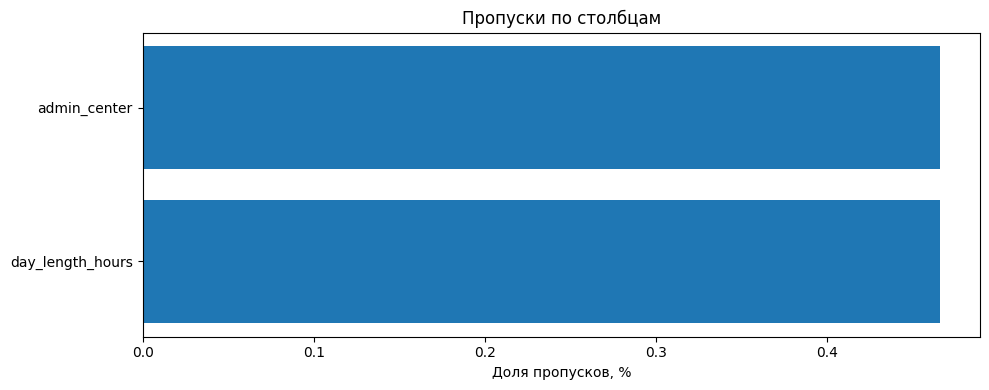

In [34]:
missing = pd.DataFrame({
    'missing_count': analysis_df.isna().sum(),
    'missing_percent': analysis_df.isna().mean() * 100
}).sort_values('missing_percent', ascending=False)

display(missing)

missing_to_plot = missing[missing['missing_count'] > 0]
if not missing_to_plot.empty:
    plt.figure(figsize=(10, max(4, len(missing_to_plot) * 0.35)))
    plt.barh(missing_to_plot.index[::-1], missing_to_plot['missing_percent'][::-1])
    plt.xlabel('Доля пропусков, %')
    plt.title('Пропуски по столбцам')
    plt.tight_layout()
    plt.show()
else:
    print('Пропусков нет.')

### Как мы видим, есть пропуски в столбцах  `admin_center`, `day_length_hours` то заполним эти данные с помощью линейной интерполяции и заполнением часто встречающимися.

- **Какие данные используются:** расширенная таблица `Extended_climate_data`, столбец даты `date`, региональный ключ `municipality` и числовой столбец `day_length_hours`, категориальный признак `admin_center`.
- **Как работает:** внутри каждого муниципалитета строки сортируются по дате, затем пропуски заполняются линейной интерполяцией.
- **Почему группируем по региону:** значения не смешиваются между разными районами/округами, поэтому интерполяция учитывает территориальную принадлежность наблюдения.
- **Что выводится:** количество пропусков до и после заполнения, чтобы сразу проверить результат.

In [ ]:
# Заполняем пропуски в числовых колонках
cols_to_interpolate = ['day_length_hours']
region_col = 'municipality'

Extended_climate_data['date'] = pd.to_datetime(
    Extended_climate_data['date'],
    errors='coerce'
)

missing_before_num = Extended_climate_data[cols_to_interpolate].isna().sum()

Extended_climate_data = Extended_climate_data.sort_values(
    [region_col, 'date']
).copy()

Extended_climate_data[cols_to_interpolate] = (
    Extended_climate_data
    .groupby(region_col, group_keys=False)[cols_to_interpolate]
    .transform(
        lambda group: group.interpolate(
            method='linear',
            limit_direction='both'
        )
    )
)

missing_after_num = Extended_climate_data[cols_to_interpolate].isna().sum()


cat_col = 'admin_center'

missing_before_cat = Extended_climate_data[cat_col].isna().sum()

def fill_random_category(group):
    existing_values = group[cat_col].dropna().unique()

    # если в группе есть хотя бы одно значение
    if len(existing_values) > 0:
        mask = group[cat_col].isna()
        group.loc[mask, cat_col] = np.random.choice(
            existing_values,
            size=mask.sum(),
            replace=True
        )

    return group

Extended_climate_data = (
    Extended_climate_data
    .groupby(region_col, group_keys=False)
    .apply(fill_random_category)
)

missing_after_cat = Extended_climate_data[cat_col].isna().sum()


# Проверка
display(pd.DataFrame({
    'missing_before_numeric': missing_before_num,
    'missing_after_numeric': missing_after_num
}))


# Проверка
display(pd.DataFrame({
    'admin_center missing before': missing_before_cat,
    'admin_center missing after': missing_after_cat
}))

,missing_before_numeric,missing_after_numeric
day_length_hours,44467,0


admin_center missing before: 44467
admin_center missing after: 0


## 4.3 Проверка дубликатов

Так как данных очень много почистим их удалив строки, где сопадают основные харарктеристики, а именно `date`, `geometry`. То есть отбросим записи в одну и ту же дату с одинаковыми координатами.

In [38]:
Extended_climate_data.duplicated(
    subset=['date', 'geometry']
).sum()


np.int64(0)

### Как мы видим, в данных полных дубликатов - нет. Однако, продемонстрируем функцию удаления, при возможном обновлении данных.

In [39]:
def drop_climate_duplicates(df):
    duplicate_cols = [
        'date',
        'geometry'
    ]
    return df.drop_duplicates(subset=duplicate_cols, keep='first')

## 4.4 Базовая описательная статистика по числовым признакам
- **Какие данные используются:** числовые столбцы `Extended_climate_data[numeric_cols]`.
- **Что выводится:** среднее, стандартное отклонение, минимум, максимум и процентили 1%, 5%, 25%, 50%, 99%.
- **Дополнительно:** если есть `municipality`, выводится частота строк по муниципалитетам.
- **Вывод:** по этой таблице удобно замечать подозрительные диапазоны, дисбаланс территорий и потенциальные выбросы.

In [41]:
display(Extended_climate_data[numeric_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.99]).T)

if 'municipality' in Extended_climate_data.columns:
    display(Extended_climate_data['municipality'].value_counts(dropna=False).to_frame('rows').head(50))

,count,mean,std,min,1%,5%,25%,50%,99%,max
lat,9538590.0,4.526794e+01,7.874366e-01,43.500000,43.600000,4.390000e+01,4.470000e+01,4.530000e+01,4.670000e+01,4.680000e+01
lon,9538590.0,3.948975e+01,1.087842e+00,36.700000,37.200000,3.770000e+01,3.860000e+01,3.950000e+01,4.150000e+01,4.170000e+01
precipitation,9538590.0,2.212138e+00,4.654797e+00,0.000000,0.000000,0.000000e+00,2.115965e-03,1.936138e-01,2.228058e+01,1.477873e+02
temp,9538590.0,1.166137e+01,9.871023e+00,-36.914237,-10.444095,-3.833428e+00,3.967285e+00,1.157797e+01,3.015985e+01,4.500000e+01
tmax,9538590.0,1.589345e+01,1.054360e+01,-32.229325,-7.130710,-7.481079e-01,7.655060e+00,1.598709e+01,3.607327e+01,4.500000e+01
tmin,9538590.0,7.243551e+00,9.311445e+00,-40.000000,-15.173689,-7.576691e+00,3.198853e-01,7.121063e+00,2.456784e+01,3.930439e+01
solar_radiation,9538590.0,8.741859e+06,5.086459e+06,0.000000,748854.934600,1.645504e+06,4.126999e+06,8.293826e+06,1.796775e+07,3.244476e+07
wind_speed,9538590.0,2.846440e+00,1.868289e+00,0.000000,0.143902,4.636234e-01,1.412098e+00,2.527722e+00,8.481687e+00,1.927107e+01
wind_direction,9538590.0,1.582255e+02,9.596401e+01,0.000000,7.186947,2.891788e+01,7.346952e+01,1.460195e+02,3.523445e+02,3.600000e+02
day_length_hours,9538590.0,1.198583e+01,2.398078e+00,8.270000,8.430000,8.600000e+00,9.650000e+00,1.198000e+01,1.556000e+01,1.573000e+01


,rows
municipality,
Мостовский район,477498
городской округ Сочи,420652
Отрадненский район,318332
Апшеронский район,295594
Новопокровский район,295594
Павловский район,284225
Кущёвский район,284225
Каневской район,284225
Приморско-Ахтарский округ,284225


## 4.5 Графики распределений и boxplot для числовых признаков

- **Какие данные используются:** случайная выборка до `100_000` строк, чтобы графики строились быстрее.
- **Что показывает histogram:** форму распределения признака и концентрацию значений.
- **Что показывает boxplot:** медиану, межквартильный размах и точки, похожие на выбросы.
- **Вывод:** эта визуальная проверка помогает понять, какие признаки требуют очистки или ограничения диапазона.

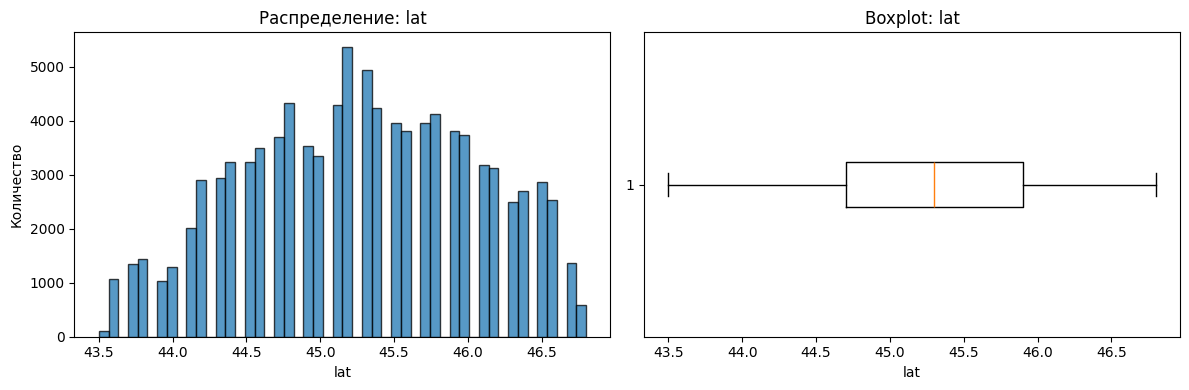

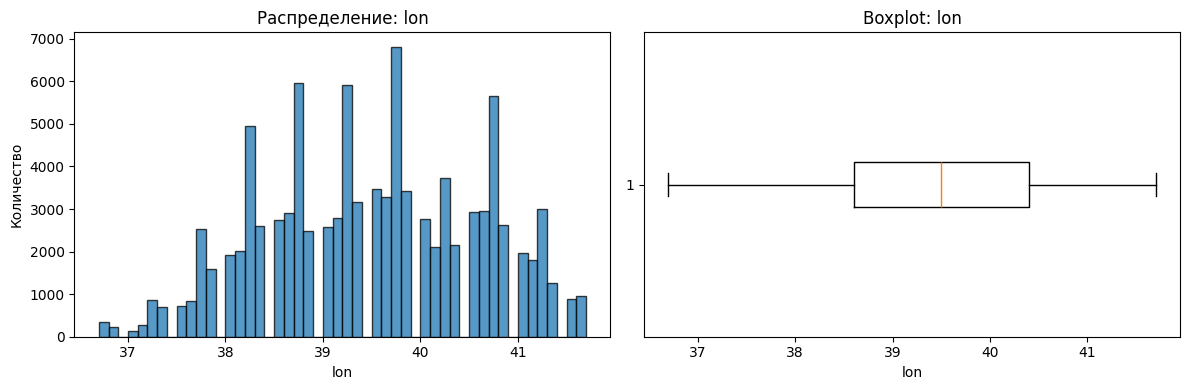

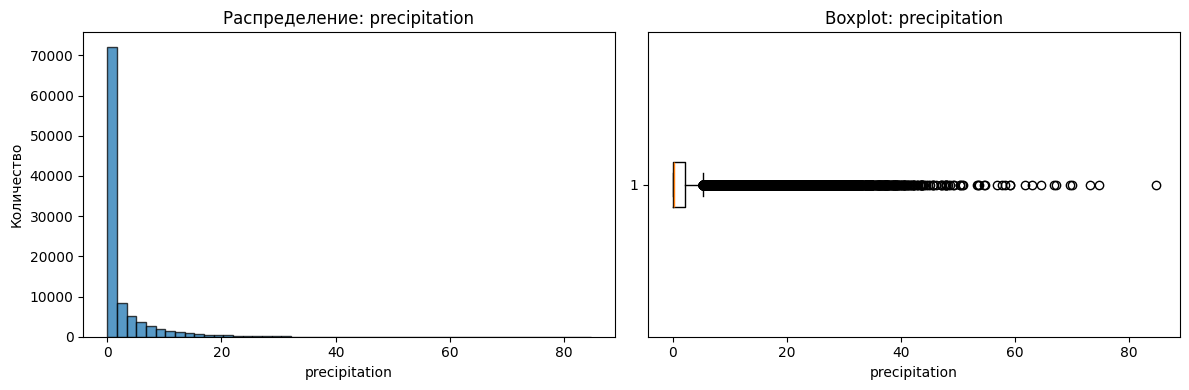

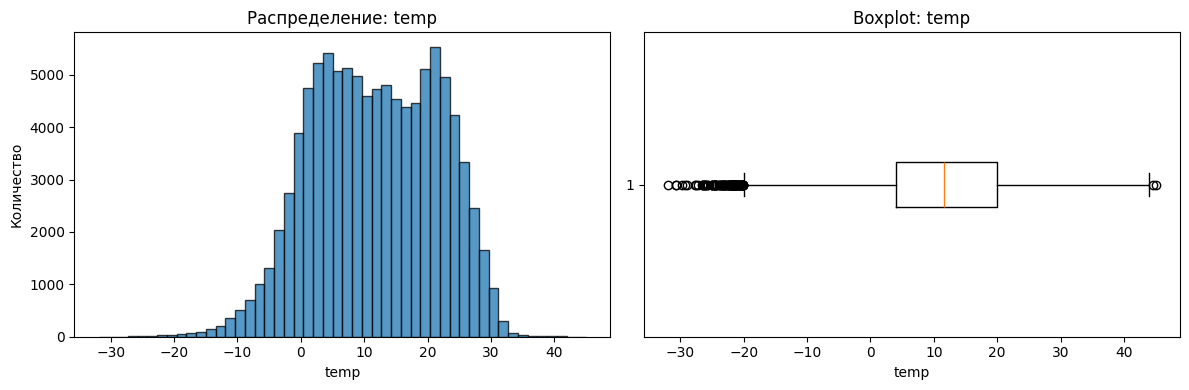

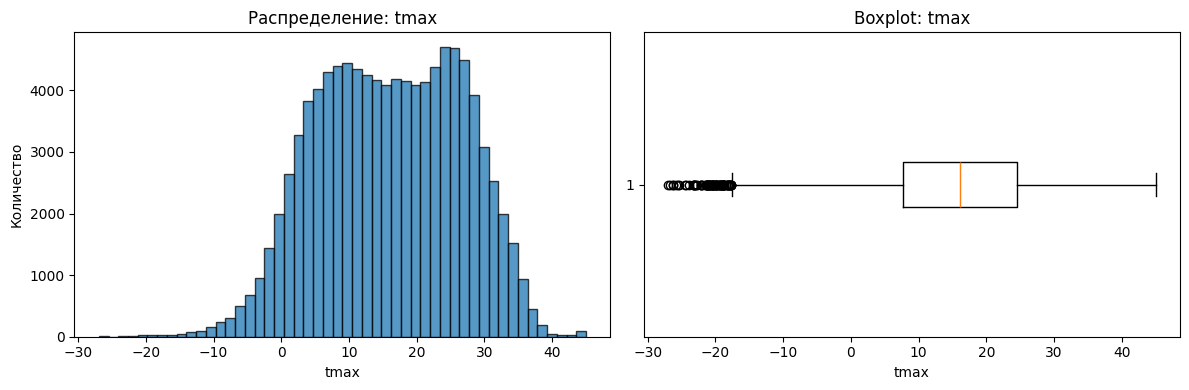

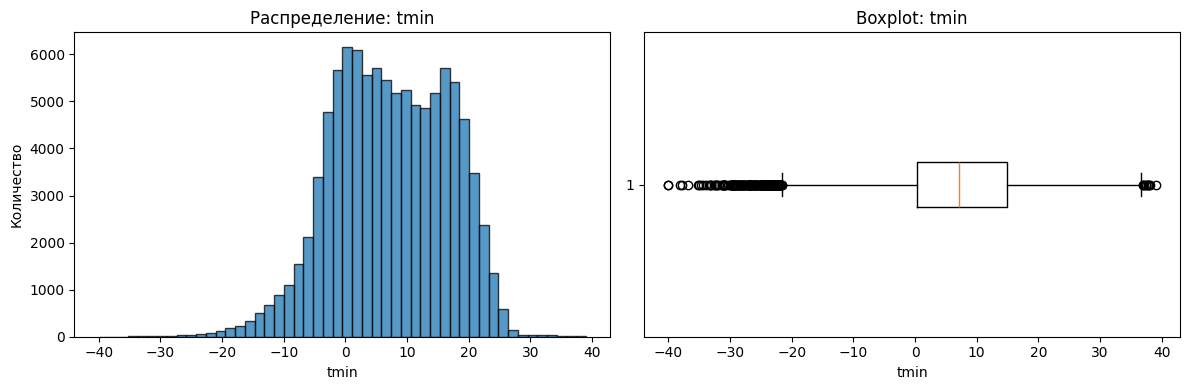

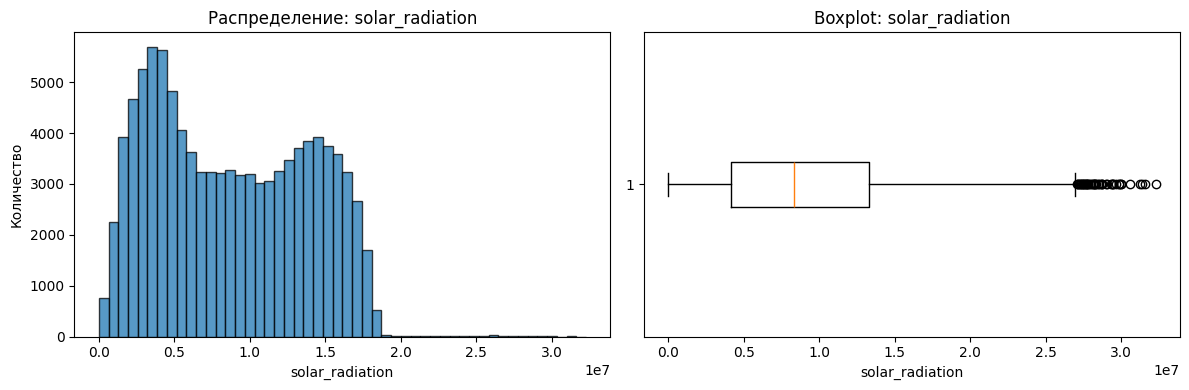

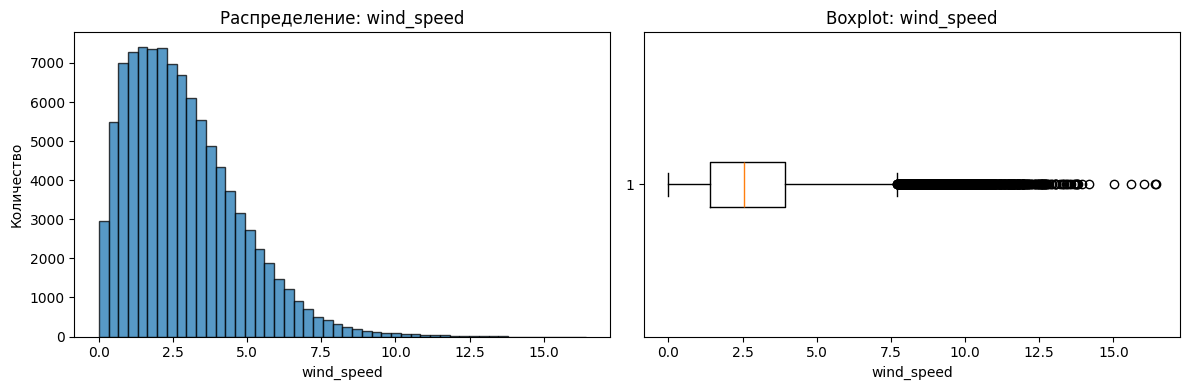

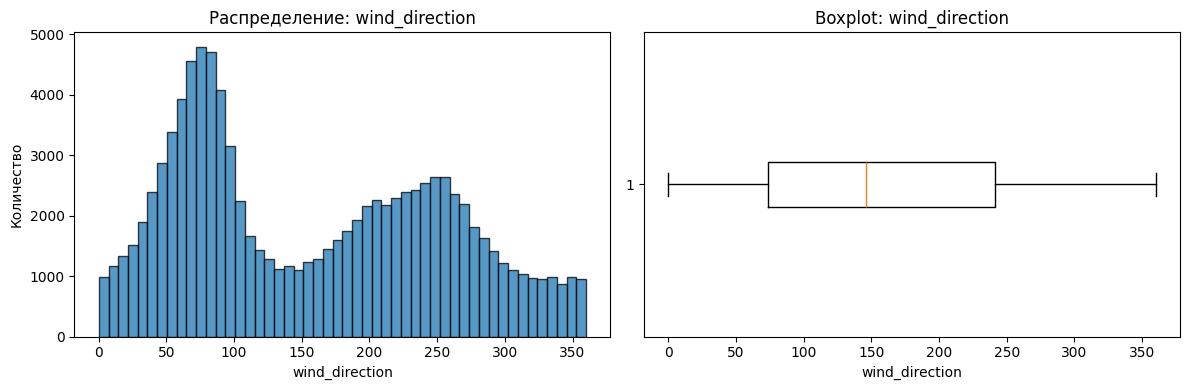

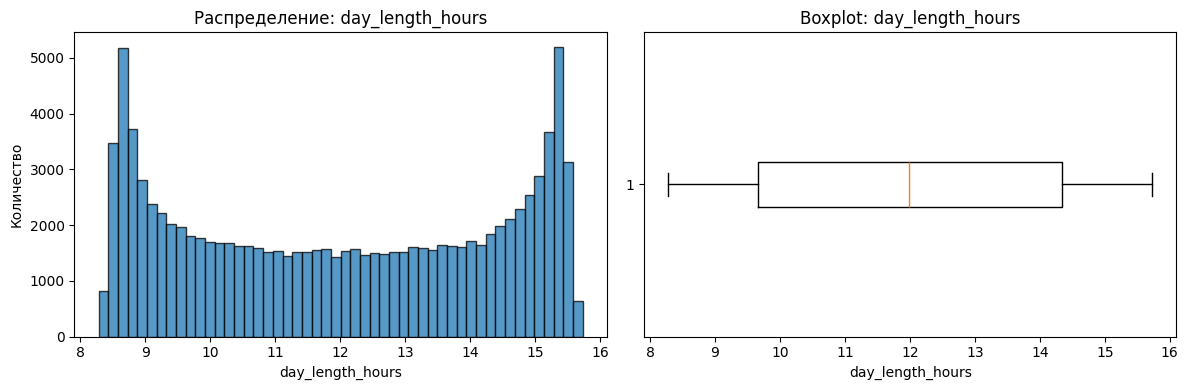

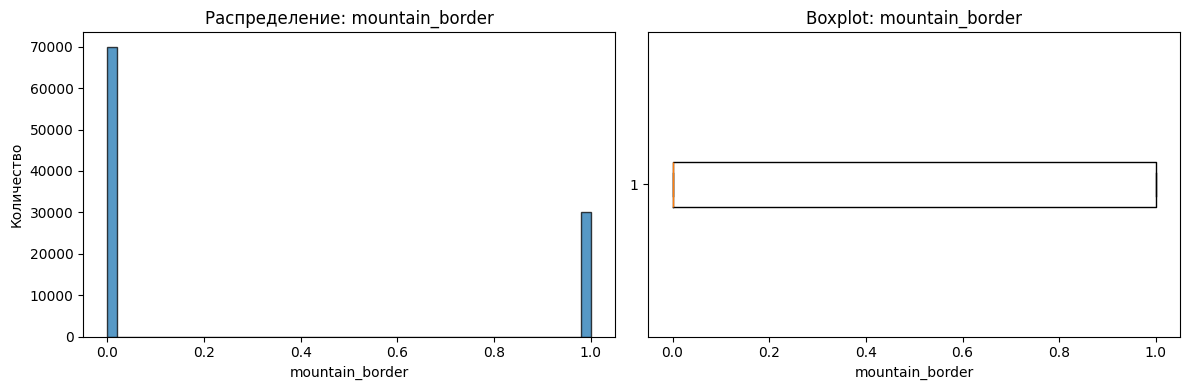

In [42]:
plot_sample = Extended_climate_data.sample(n=min(100_000, len(Extended_climate_data)), random_state=42)
plot_numeric_cols = [col for col in numeric_cols if plot_sample[col].notna().any()]

for col in plot_numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(plot_sample[col].dropna(), bins=50, edgecolor='black', alpha=0.75)
    axes[0].set_title(f'Распределение: {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Количество')

    axes[1].boxplot(plot_sample[col].dropna(), vert=False)
    axes[1].set_title(f'Boxplot: {col}')
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

## 4.6 Потенциальные выбросы
- **Назначение:** формируется таблица потенциальных выбросов по методу IQR.
- **Какие данные используются:** все числовые признаки.
- **Как работает IQR:** значения ниже `Q1 - 1.5 * IQR` или выше `Q3 + 1.5 * IQR` считаются потенциальными выбросами.
- **Что создаётся:** `outlier_summary` с границами, количеством и процентом выбросов по каждому признаку.

In [43]:
outlier_rows = []
outlier_masks = {}

for col in numeric_cols:
    s = Extended_climate_data[col].dropna()
    if s.empty:
        continue

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = Extended_climate_data[col].notna() & ((Extended_climate_data[col] < lower) | (Extended_climate_data[col] > upper))
    outlier_masks[col] = mask
    outlier_rows.append({
        'column': col,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_bound': lower,
        'upper_bound': upper,
        'outlier_count': int(mask.sum()),
        'outlier_percent': mask.mean() * 100,
        'min': s.min(),
        'max': s.max(),
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values('outlier_percent', ascending=False)
display(outlier_summary)

,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percent,min,max
2,precipitation,2.115965e-03,2.144552e+00,2.142436e+00,-3.211538e+00,5.358206e+00,1285629,13.478187,0.000000,1.477873e+02
7,wind_speed,1.412098e+00,3.926936e+00,2.514838e+00,-2.360159e+00,7.699193e+00,164791,1.727624,0.000000,1.927107e+01
5,tmin,3.198853e-01,1.494504e+01,1.462515e+01,-2.161784e+01,3.688277e+01,22725,0.238243,-40.000000,3.930439e+01
3,temp,3.967285e+00,1.995071e+01,1.598343e+01,-2.000786e+01,4.392586e+01,9707,0.101766,-36.914237,4.500000e+01
4,tmax,7.655060e+00,2.452921e+01,1.687415e+01,-1.765616e+01,4.984042e+01,8478,0.088881,-32.229325,4.500000e+01
6,solar_radiation,4.126999e+06,1.329436e+07,9.167360e+06,-9.624041e+06,2.704540e+07,4064,0.042606,0.000000,3.244476e+07
0,lat,4.470000e+01,4.590000e+01,1.200000e+00,4.290000e+01,4.770000e+01,0,0.000000,43.500000,4.680000e+01
1,lon,3.860000e+01,4.040000e+01,1.800000e+00,3.590000e+01,4.310000e+01,0,0.000000,36.700000,4.170000e+01
8,wind_direction,7.346952e+01,2.411306e+02,1.676611e+02,-1.780222e+02,4.926223e+02,0,0.000000,0.000000,3.600000e+02
9,day_length_hours,9.650000e+00,1.432000e+01,4.670000e+00,2.645000e+00,2.132500e+01,0,0.000000,8.270000,1.573000e+01


## 4.7 Очистим выбросы

### План очистики:
 - `Температуры` — удалить только физически подозрительные значения.
 - `Ветер и радиация` — лучше обрезать по верхней границе IQR или по 99.5/99.9 перцентилю.
 - `lat`, `lon`, `day`, `month`, `year`, `day_length_hours`, `mountain_border` не трогать: выбросов нет.

### 4.7.1 Примеры строк с выбросами

- **Назначение:** показываются конкретные строки с выбросами для самых проблемных числовых признаков.
- **Какие данные используются:** `outlier_summary` и маски `outlier_masks`, созданные в предыдущей ячейке.
- **Что выводится:** по каждому признаку показываются самые маленькие и самые большие значения с контекстом даты, координат и муниципалитета.
- **Вывод:** эта ячейка помогает отличить реальные экстремальные погодные условия от ошибок данных.

In [44]:
cols_to_show = [
    col
    for col in ['date', 'lat', 'lon', 'municipality', 'admin_center']
    if col in Extended_climate_data.columns
]

for col in outlier_summary['column'].head(10):
    print(f'\nВыбросы для {col}')

    display_cols = list(dict.fromkeys(cols_to_show + [col]))
    outlier_examples = Extended_climate_data.loc[outlier_masks[col], display_cols]

    display(outlier_examples.sort_values(by=col).head(5))
    display(outlier_examples.sort_values(by=col, ascending=False).head(5))



Выбросы для precipitation


,date,lat,lon,municipality,admin_center,precipitation
1038928,1998-05-23,44.8,38.6,Северский район,Северская,5.358212
9426210,2025-10-05,44.0,39.6,городской округ Сочи,Сочи,5.358213
3778110,2007-05-01,44.2,41.7,Отрадненский район,Отрадная,5.358226
4036322,2008-03-03,46.2,40.9,Белоглинский район,Белая Глина,5.358228
5654950,2013-06-15,44.2,41.4,Отрадненский район,Отрадная,5.358234


,date,lat,lon,municipality,admin_center,precipitation
8156328,2021-08-13,45.3,37.1,Темрюкский район,Темрюк,147.78728
8156327,2021-08-13,45.3,37.0,Темрюкский район,Темрюк,137.06854
8156285,2021-08-13,45.2,37.1,Темрюкский район,Темрюк,136.94243
8156329,2021-08-13,45.3,37.2,Темрюкский район,Темрюк,133.67151
8156719,2021-08-13,46.6,37.8,Ейский район,Ейск,125.64464



Выбросы для wind_speed


,date,lat,lon,municipality,admin_center,wind_speed
9247929,2025-03-06,45.4,39.6,Кореновский район,Кореновск,7.699198
8612638,2023-02-08,45.0,37.7,Крымский район,Крымск,7.699201
9163497,2024-11-25,46.5,38.1,Ейский район,Ейск,7.699202
4960143,2011-03-09,46.6,39.4,Кущёвский район,Кущёвская,7.699237
3737740,2007-03-13,46.8,38.6,Щербиновский район,Старощербиновская,7.699241


...

,date,lat,lon,municipality,admin_center,wind_direction


,date,lat,lon,municipality,admin_center,wind_direction



Выбросы для day_length_hours


,date,lat,lon,municipality,admin_center,day_length_hours


,date,lat,lon,municipality,admin_center,day_length_hours


### 4.7.2 Функция удаления выбросов

In [45]:
def clean_climate_outliers(df):
    df = df.copy()

    # Удаляем только физически невозможные или логически противоречивые температуры.
    valid_temperature = (
        df['temp'].between(-45, 50)
        & df['tmin'].between(-45, 45)
        & df['tmax'].between(-45, 55)
        & (df['tmin'] <= df['temp'])
        & (df['temp'] <= df['tmax'])
    )
    removed_temperature_rows = (~valid_temperature).sum()
    df = df.loc[valid_temperature].copy()

    # Длинные правые хвосты осадков, ветра и радиации не удаляем, а winsorize/clip.
    # Так мы сохраняем строки, но ограничиваем экстремальные значения.
    clip_quantiles = {
        'precipitation': 0.999,
        'wind_speed': 0.999,
        'solar_radiation': 0.999
    }

    clip_report = []
    for col, q in clip_quantiles.items():
        upper = df[col].quantile(q)
        values_above = (df[col] > upper).sum()
        values_below_zero = (df[col] < 0).sum()
        df[col] = df[col].clip(lower=0, upper=upper)
        clip_report.append({
            'column': col,
            'upper_quantile': q,
            'upper_value': upper,
            'values_clipped_above': int(values_above),
            'values_clipped_below_zero': int(values_below_zero),
        })

    valid_wind_direction = df['wind_direction'].between(0, 360)
    removed_wind_direction_rows = (~valid_wind_direction).sum()
    df = df.loc[valid_wind_direction].copy()

    report = {
        'removed_temperature_rows': int(removed_temperature_rows),
        'removed_wind_direction_rows': int(removed_wind_direction_rows),
        'clip_report': pd.DataFrame(clip_report)
    }

    return df, report


### 4.7.3 Посмотрим статистику очистки

In [46]:
before_shape = Extended_climate_data.shape

Extended_climate_data, outlier_cleaning_report = clean_climate_outliers(Extended_climate_data)

after_shape = Extended_climate_data.shape
analysis_df = Extended_climate_data.copy()
numeric_cols = analysis_df.select_dtypes(include='number').columns.tolist()
categorical_cols = analysis_df.select_dtypes(exclude='number').columns.tolist()

print('До очистки:', before_shape)
print('После очистки:', after_shape)
print('Удалено строк:', before_shape[0] - after_shape[0])
print('Удалено из-за температур:', outlier_cleaning_report['removed_temperature_rows'])
print('Удалено из-за направления ветра:', outlier_cleaning_report['removed_wind_direction_rows'])

display(outlier_cleaning_report['clip_report'])


До очистки: (9538590, 17)
После очистки: (9309439, 17)
Удалено строк: 229151
Удалено из-за температур: 229151
Удалено из-за направления ветра: 0


,column,upper_quantile,upper_value,values_clipped_above,values_clipped_below_zero
0,precipitation,0.999,3.923320e+01,9310,0
1,wind_speed,0.999,1.167630e+01,9310,0
2,solar_radiation,0.999,2.487140e+07,9310,0


## 4.8 Графики статистик средних значений показателей по месяцам

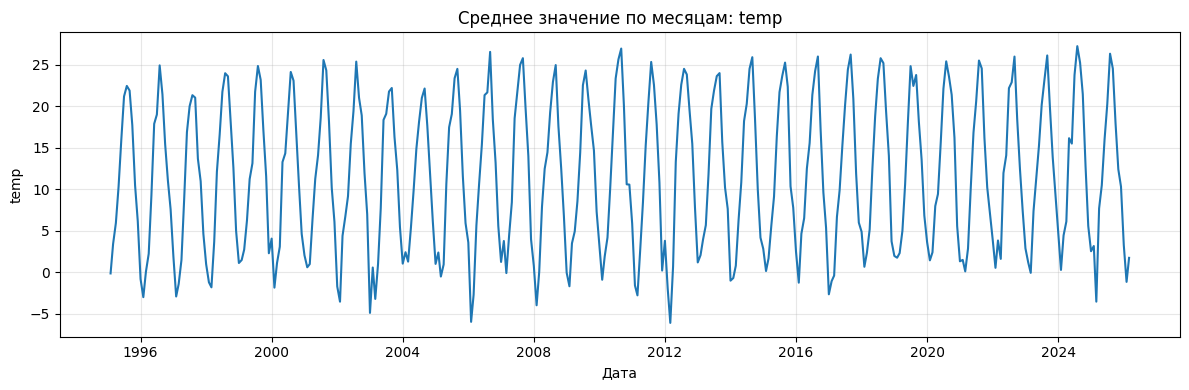

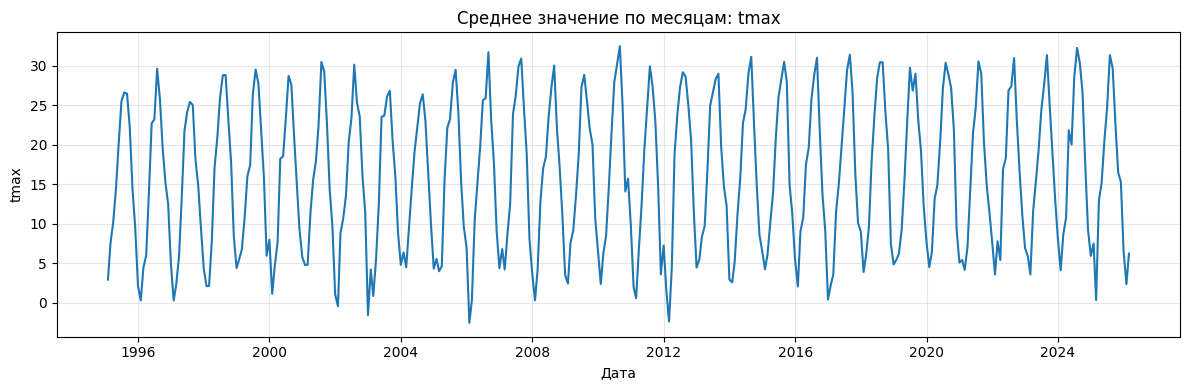

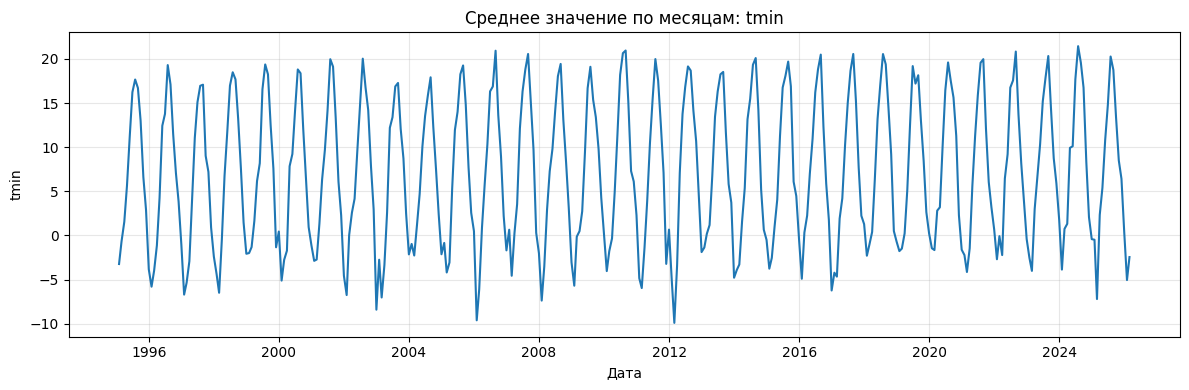

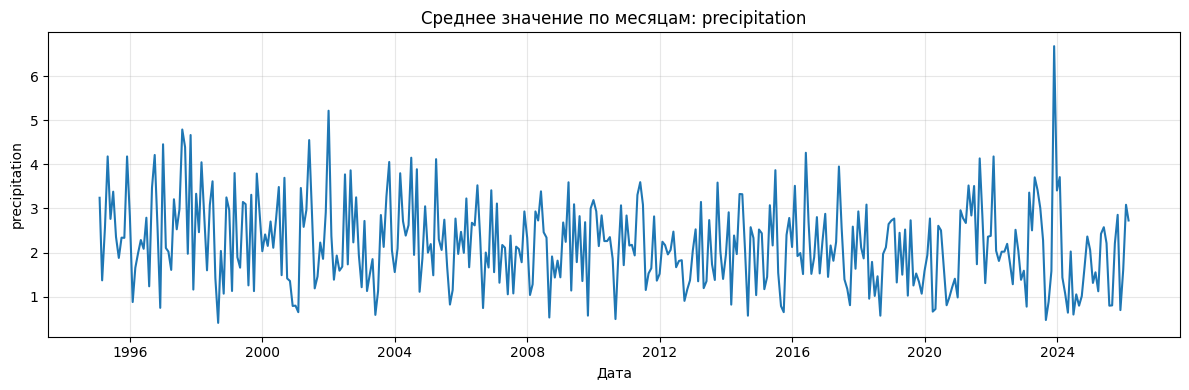

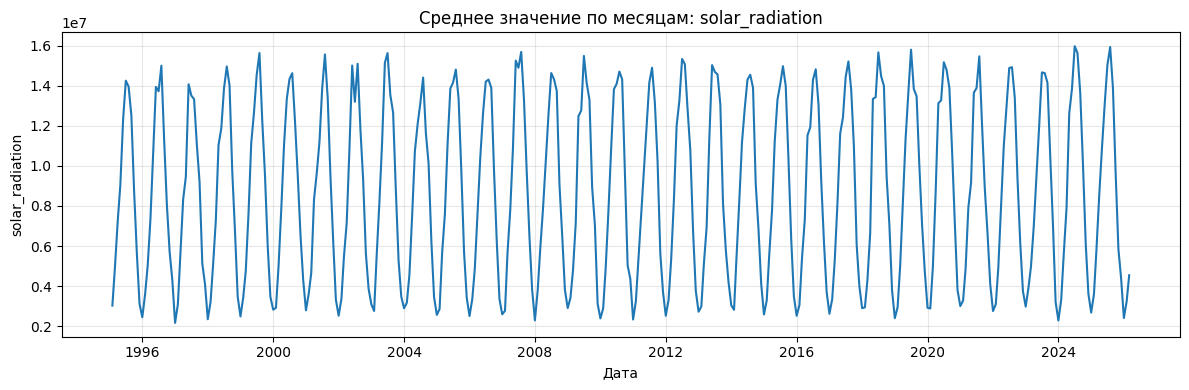

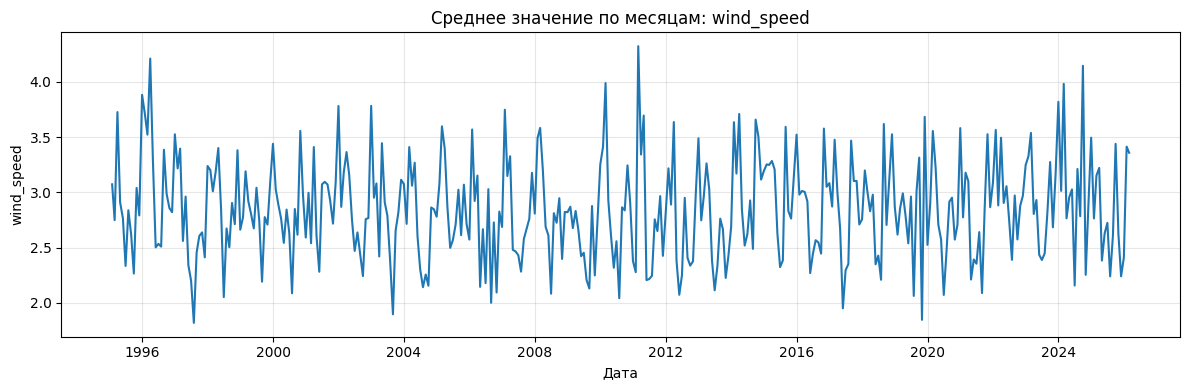

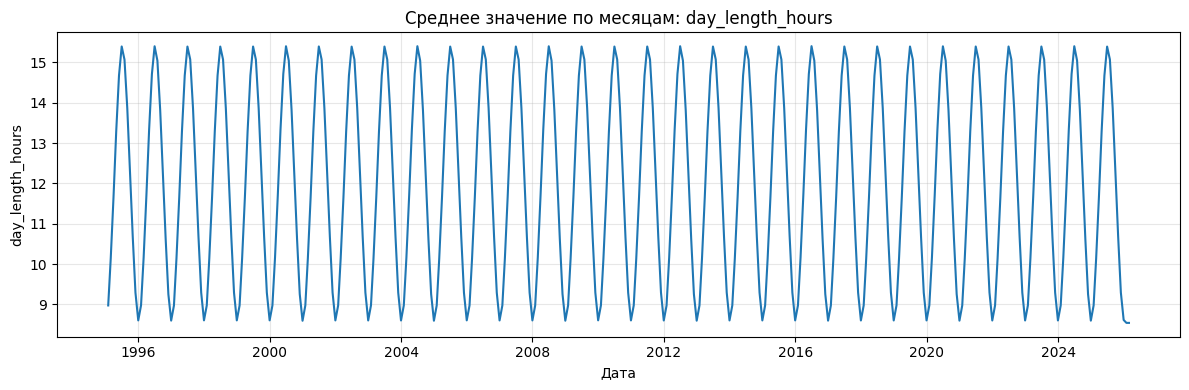

In [47]:
time_numeric_cols = [col for col in ['temp', 'tmax', 'tmin', 'precipitation', 'solar_radiation', 'wind_speed', 'day_length_hours'] if col in analysis_df.columns]

monthly = (
    analysis_df
    .dropna(subset=['date'])
    .set_index('date')[time_numeric_cols]
    .resample('ME')
    .mean()
)

for col in monthly.columns:
    plt.figure(figsize=(12, 4))
    plt.plot(monthly.index, monthly[col])
    plt.title(f'Среднее значение по месяцам: {col}')
    plt.xlabel('Дата')
    plt.ylabel(col)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
Extended_climate_data = Extended_climate_data.drop(columns=['region_polygon', 'municipality'], errors='ignore')

# 5. Проверка размерности и сохранение итогового датасэта в csv

In [51]:
size_in_bytes = Extended_climate_data.memory_usage(deep=True).sum()
size_in_gb = size_in_bytes / (1024 ** 3)
print(f"Размер таблицы: {size_in_gb:.2f} ГБ")

Размер таблицы: 2.85 ГБ


In [52]:
with open('data.csv', 'w', encoding='utf-8') as f:
    f.write(','.join(Extended_climate_data.columns) + '\n')
    for _, row in tqdm(Extended_climate_data.iterrows(), total=len(Extended_climate_data)):
        f.write(','.join(map(str, row.values)) + '\n')

  0%|          | 0/9309439 [00:00<?, ?it/s]